# Grid Prediction for a Single Day

Runs the full two-stage Ordinary Kriging pipeline for one day:
1. Load data & fit transforms (on full year for proper NST CDF)
2. Load pre-fitted global variograms
3. Build prediction grid
4. Run OrdinaryKrigingModel.fit() + predict() via production code
5. Visualize prediction + uncertainty maps

In [ ]:
import sys, os, time
from pathlib import Path

# Two levels up from notebooks/tool/ to project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

print(f"Working directory: {os.getcwd()}")

## 1. Load data & fit transforms

In [2]:
from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import (
    ProjectionTransform, IndicatorTransform,
    DetrendTransform, NormalScoreTransform, LogTransform, KrigingTransform,
)
from thesis.transforms.pipeline import TransformPipeline

cfg = Config()
registry = DataRegistry.from_config(cfg)

# ── Load full date range for proper pipeline fitting ──
# DetrendTransform needs many days to compute monthly totals.
# NormalScoreTransform needs thousands of wet quotas for a proper CDF.
# Loading only 1 day → all quotas = 1.0 (degenerate) → garbage predictions.
print("Loading ReKIS data...")
all_raw = registry.stations.load(cfg.date_start, cfg.date_end)
print(f"Loaded {len(all_raw):,} rows, {all_raw['station_id'].nunique()} stations")

# ── Fit pipeline (same order as run_cv.py) ──
print("\nFitting pipeline...")
proj  = ProjectionTransform(target_crs=cfg.study_area.target_crs)
ind   = IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm)
det   = DetrendTransform()
ns    = NormalScoreTransform()
log_t = LogTransform(offset=cfg.log_transform_offset)

proj.fit(all_raw);  current = proj.apply(all_raw)
ind.fit(current);   current = ind.apply(current)
det.fit(current);   current = det.apply(current)
ns.fit(current)

all_proc = current
print(f"Pipeline fitted. Shape: {all_proc.shape}")
print(f"NST CDF: {len(ns._sorted_vals):,} wet quotas")

Loading ReKIS data...
Loaded 56,558,580 rows, 2458 stations

Fitting pipeline...
Pipeline fitted. Shape: (56558580, 10)
NST CDF: 21,745,253 wet quotas


## 2. Load variograms & build grid

In [5]:
from thesis.models.kriging.variogram_fitter import GlobalVariogramFitter
from thesis.datasets.protocols import PredictionGrid

# ── Load variograms ──
vgm_path = Path("results/ordinary_kriging/global_variograms.pkl")
if not vgm_path.exists():
    vgm_path = Path("outputs/ordinary_kriging/global_variograms.pkl")
global_vgm = GlobalVariogramFitter.load(str(vgm_path))

print(f"Variograms: {list(global_vgm.keys())}")

# ── Build prediction grid ──
print("\nBuilding prediction grid...")
grid = PredictionGrid.from_config(cfg, dem=registry.dem)
print(f"Grid: {grid.n_cells():,} cells, shape {grid.shape}")

Loaded: results/ordinary_kriging/global_variograms.pkl  (10 combinations)
Variograms: [('none', 'spherical'), ('none', 'exponential'), ('none', 'gaussian'), ('log', 'spherical'), ('log', 'exponential'), ('log', 'gaussian'), ('normal_score', 'spherical'), ('normal_score', 'exponential'), ('normal_score', 'gaussian'), ('indicator', 'spherical')]

Building prediction grid...
Grid: 257,922 cells, shape (534, 483)


## 3. Select a day

In [6]:
# ═══════════════════════════════════════════════════════════
# CHANGE THIS to explore different days
# ═══════════════════════════════════════════════════════════
test_date = '2013-11-24'

proc_day = all_proc[all_proc['date'] == test_date].copy()
n_wet = int((proc_day['rain_indicator'] == 1).sum())
print(f"Date: {test_date}")
print(f"Stations: {len(proc_day)}, wet: {n_wet}")
print(f"Max precip: {proc_day['precip_mm'].max():.1f} mm")
print(f"Mean wet-day: {proc_day[proc_day['rain_indicator']==1]['precip_mm'].mean():.2f} mm")

Date: 2013-11-24
Stations: 2458, wet: 1180
Max precip: 5.5 mm
Mean wet-day: 1.00 mm


## 4. Build StationDataset & run prediction

Uses `OrdinaryKrigingModel` from `src/thesis/models/kriging/ordinary.py` directly:
- Cholesky factorisation of SPD covariance matrix (not augmented system)
- Analytic Lagrange multiplier
- MC back-transformation for unbiased mean

In [7]:
from thesis.models.kriging.ordinary import OrdinaryKrigingModel
from thesis.datasets.protocols import StationDataset

# ── Build StationDataset for the chosen day ──
month_num = int(test_date[5:7])
norm_lookup = det._monthly_totals.xs(month_num, level="_month")

monthly_norms = proc_day["station_id"].map(norm_lookup).fillna(float(norm_lookup.mean())).values
elev = proc_day["elevation_m"].values if "elevation_m" in proc_day.columns else None

ds = StationDataset(
    coords_proj=proc_day[["x_proj", "y_proj"]].values,
    precip_quota=proc_day["precip_quota"].values,
    rain_indicator=proc_day["rain_indicator"].values,
    monthly_normals=monthly_norms.astype(float),
    elevation_m=elev,
    date=test_date,
    crs=cfg.study_area.target_crs,
)
print(f"StationDataset: {ds.n_stations()} stations, wet: {ds.wet_mask().sum()}")

StationDataset: 2458 stations, wet: 1180


In [8]:
norm_grids_path = Path("results/ordinary_kriging/monthly_norm_grids.pkl")
if not norm_grids_path.exists():
    raise FileNotFoundError(
        "Monthly norm grids not found. Run `python -m thesis.scripts.build_monthly_grids` first."
    )

data = pd.read_pickle(norm_grids_path)
grids_2d, grids_3d = data.get('grids_2d'), data.get('grids_3d')

In [9]:
# CHANGE THESE to explore different transforms / models
TRANSFORM = 'normal_score'   # "none", "log", "normal_score"
VGMODEL   = 'exponential'    # "spherical", "exponential", "gaussian"

kt = KrigingTransform(kind=TRANSFORM, ns=ns, log=log_t)
base_pipeline = TransformPipeline([proj, ind, det])
base_pipeline._fitted = True

model = OrdinaryKrigingModel(
    cfg, base_pipeline,
    fwd_fn=lambda q: kt.fwd(q),
    inv_fn=lambda z: kt.inv(z),
)
model.set_global_variogram(global_vgm, transform=TRANSFORM, amount_model=VGMODEL)
model.set_monthly_norm_grids(grids_2d, grids_3d)

t0 = time.time()
model.fit(ds)
result = model.predict(grid)
elapsed = time.time() - t0

mm = result.mean.values.ravel()
print(f"{TRANSFORM} + {VGMODEL} -> {mm.min():.2f}–{mm.max():.2f} mm  ({elapsed:.1f}s)")

if result.variance is not None:
    std = np.sqrt(np.maximum(result.variance.values, 0.0))
    print(f"Kriging std range: {std.min():.2f}–{std.max():.2f} mm")

normal_score + exponential -> 0.00–4.11 mm  (125.6s)
Kriging std range: 0.00–4.73 mm


## 5. Visualize prediction + uncertainty maps

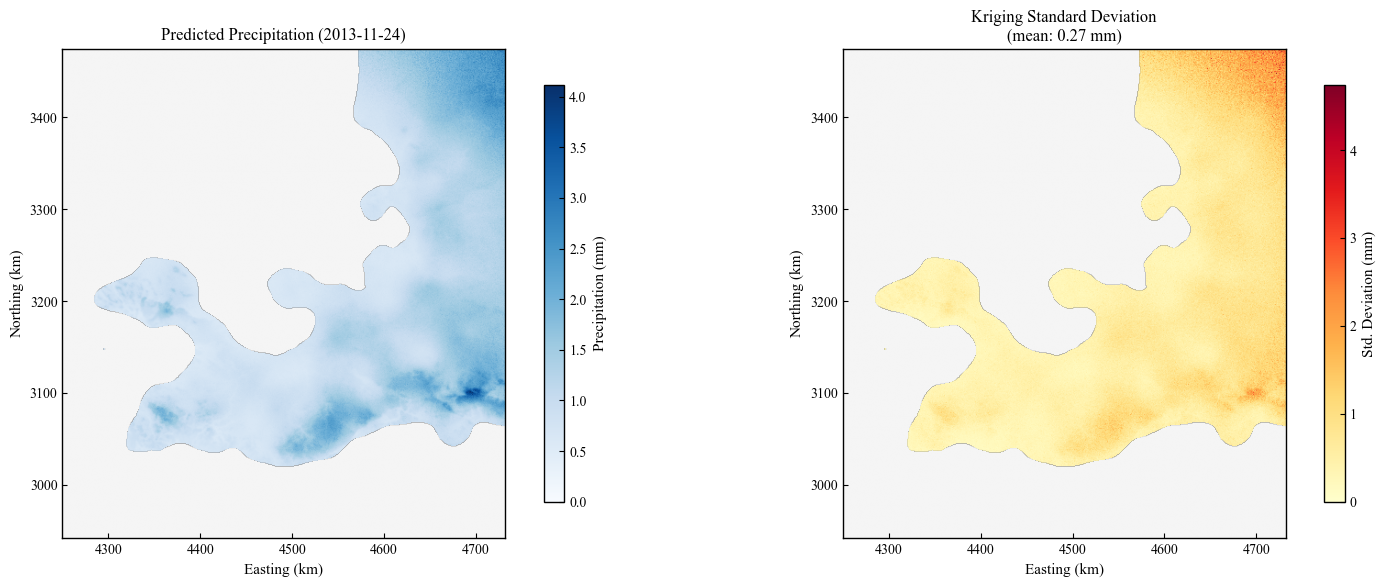

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Plot style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12
})

H, W = grid.shape
gx_2d = grid.coords_proj[:, 0].reshape(H, W)
gy_2d = grid.coords_proj[:, 1].reshape(H, W)
ext_km = [gx_2d[0,0]/1e3, gx_2d[0,-1]/1e3, gy_2d[0,0]/1e3, gy_2d[-1,0]/1e3]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Light-gray background for cells inside the grid domain
domain_bg = np.where(~np.isnan(pred), 1, np.nan)
cmap_bg = ListedColormap(['#f5f5f5'])

# ── Left panel: prediction ──
ax1 = axes[0]
ax1.set_facecolor('white')
ax1.imshow(domain_bg, cmap=cmap_bg, origin='lower', extent=ext_km)

# Mask dry cells, draw only wet areas
pred_masked = np.ma.masked_where((pred <= 0.01) | np.isnan(pred), pred)
im1 = ax1.imshow(pred_masked, cmap='Blues', vmin=0, vmax=pred.max(), 
                 origin='lower', extent=ext_km)

plt.colorbar(im1, ax=ax1, label='Precipitation (mm)', shrink=0.85)

ax1.set_title(f'Predicted Precipitation ({test_date})')
ax1.set_xlabel('Easting (km)')
ax1.set_ylabel('Northing (km)')

# ── Right panel: uncertainty ──
ax2 = axes[1]
ax2.set_facecolor('white')
ax2.imshow(domain_bg, cmap=cmap_bg, origin='lower', extent=ext_km)

# Mask near-zero std
std_masked = np.ma.masked_where((std_mm <= 0.001) | np.isnan(std_mm), std_mm)
im2 = ax2.imshow(std_masked, cmap='YlOrRd', vmin=0, vmax=std_mm.max(), 
                 origin='lower', extent=ext_km)

plt.colorbar(im2, ax=ax2, label='Std. Deviation (mm)', shrink=0.85)

ax2.set_title(f'Kriging Standard Deviation\n(mean: {std_mm.mean():.2f} mm)')
ax2.set_xlabel('Easting (km)')
ax2.set_ylabel('Northing (km)')

for ax in axes:
    ax.grid(False)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()